In [3]:
!pip install contractions wordcloud -q

In [4]:
# Basic libraries
import os
import zipfile
import re
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from contractions import fix

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# TensorFlow / Keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [5]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [7]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import os

os.listdir('/content/drive/MyDrive')

['Untitled document (8).gdoc',
 'Cyber security and AI Pitch.gdoc',
 'Colab Notebooks',
 '5CS037',
 'Middle_East_Dataset.csv',
 'South_Asia_Dataset.csv',
 'Cover Page (1).gdoc',
 'Cover Page.gdoc',
 '2406805_Sikha_Gajmer.gdoc',
 'Sikha_2406805_Tut6.gdoc',
 'Untitled document (7).gdoc',
 'Untitled document (6).gdoc',
 'sikha_worksheet8.ipynb',
 'sikha_worshop 9.ipynb',
 '2406805_Sikha_Gajmer.ipynb',
 'aiassignment',
 'Attendance (2).gsheet',
 'Attendance (1).gsheet',
 'NepNews',
 'Attendance.gsheet',
 'Untitled form.gform',
 'Blank Quiz.gform',
 'HCI',
 'Untitled presentation.gslides',
 'FYP Project 2406805_Sikha_Gajmer',
 'Untitled document (5).gdoc',
 'Untitled document (4).gdoc',
 'Untitled document (3).gdoc',
 'Untitled document (2).gdoc',
 'Untitled document (1).gdoc',
 'Untitled document.gdoc',
 'Week4_workshop.gdoc',
 'Week1_Workshop.gdoc',
 '6CS005  Pre- Requiste Workshop 2 Part 2.gdoc',
 'First portfolio_2406805.app',
 '1st Assessment.zip',
 '6CS005 - Assessment 25-26.docx.pdf'

In [13]:
import zipfile

# Correct zip path
zip_path = '/content/drive/MyDrive/ Movie Review Dataset.zip'

# Folder to extract dataset
extract_path = '/content/movie_review_dataset'

# Extract zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [14]:
import os

os.listdir(extract_path)

['__MACOSX', '5. Movie Review Dataset']

In [15]:
base_dir = '/content/movie_review_dataset/5. Movie Review Dataset'

os.listdir(base_dir)

['train_movie_review.csv',
 'val_movie_review.csv',
 'test_movie_review.csv',
 '5.Description Movie Review Dataset.txt']

In [16]:
import pandas as pd

# Load datasets
train_df = pd.read_csv(
    '/content/movie_review_dataset/5. Movie Review Dataset/train_movie_review.csv'
)

val_df = pd.read_csv(
    '/content/movie_review_dataset/5. Movie Review Dataset/val_movie_review.csv'
)

test_df = pd.read_csv(
    '/content/movie_review_dataset/5. Movie Review Dataset/test_movie_review.csv'
)

# Display first rows
train_df.head()

,Unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0
3,6703,A lot people get hung up on this films tag as ...,1
4,28168,I was a fan of Buffy and hoped it would come t...,0


In [17]:
print("Training Shape:", train_df.shape)

print("Validation Shape:", val_df.shape)

print("Testing Shape:", test_df.shape)

Training Shape: (35000, 3)
Validation Shape: (5000, 3)
Testing Shape: (10000, 3)


In [18]:
train_df.columns

Index(['Unnamed: 0', 'review', 'sentiment'], dtype='object')

In [19]:
# Remove unnecessary index column

train_df = train_df.drop(columns=['Unnamed: 0'])

val_df = val_df.drop(columns=['Unnamed: 0'])

test_df = test_df.drop(columns=['Unnamed: 0'])

# Check dataset
train_df.head()

,review,sentiment
0,"Having avoided seeing the movie in the cinema,...",0
1,With this movie I was really hoping that the i...,0
2,Raymond Burr stars as an attorney caught up in...,0
3,A lot people get hung up on this films tag as ...,1
4,I was a fan of Buffy and hoped it would come t...,0


In [20]:
train_df['sentiment'].value_counts()

,count
sentiment,
0,17584
1,17416


In [21]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [22]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from contractions import fix

# Stopwords
stop_words = set(stopwords.words('english'))

# Lemmatizer
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Expand contractions
    text = fix(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [23]:
train_df['cleaned_review'] = train_df['review'].apply(clean_text)

val_df['cleaned_review'] = val_df['review'].apply(clean_text)

test_df['cleaned_review'] = test_df['review'].apply(clean_text)

# Check output
train_df.head()

,review,sentiment,cleaned_review
0,"Having avoided seeing the movie in the cinema,...",0,avoided seeing movie cinema buying dvd wife xm...
1,With this movie I was really hoping that the i...,0,movie really hoping idea make hashed together ...
2,Raymond Burr stars as an attorney caught up in...,0,raymond burr star attorney caught murder best ...
3,A lot people get hung up on this films tag as ...,1,lot people get hung film tag childrens film ce...
4,I was a fan of Buffy and hoped it would come t...,0,fan buffy hoped would come proper end angel go...


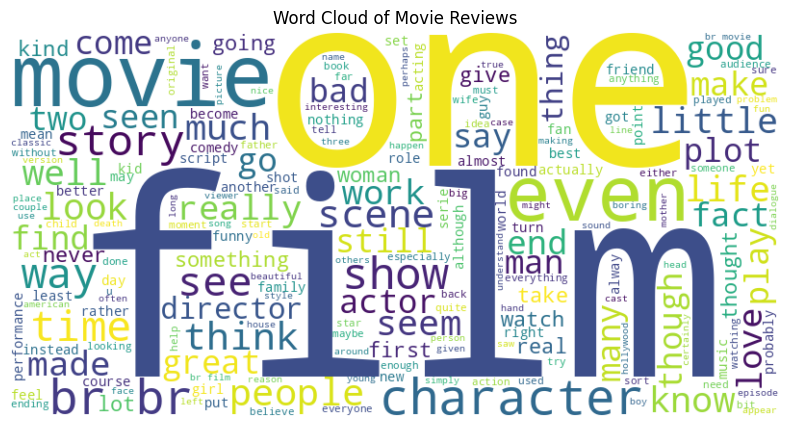

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned reviews
all_words = " ".join(train_df['cleaned_review'])

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

# Display word cloud
plt.figure(figsize=(10,5))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Word Cloud of Movie Reviews")

plt.show()

In [25]:
X_train = train_df['cleaned_review']

y_train = train_df['sentiment']

X_val = val_df['cleaned_review']

y_val = val_df['sentiment']

X_test = test_df['cleaned_review']

y_test = test_df['sentiment']

In [26]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Vocabulary size
vocab_size = 10000

# Tokenizer
tokenizer = Tokenizer(num_words=vocab_size)

# Fit tokenizer
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_val_seq = tokenizer.texts_to_sequences(X_val)

X_test_seq = tokenizer.texts_to_sequences(X_test)

In [27]:
import numpy as np

# Sequence lengths
sequence_lengths = [len(seq) for seq in X_train_seq]

# 95th percentile
max_length = int(np.percentile(sequence_lengths, 95))

print("Max Length:", max_length)

Max Length: 270


In [28]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_length,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)

print(X_train_pad.shape)
print(X_val_pad.shape)
print(X_test_pad.shape)

(35000, 270)
(5000, 270)
(10000, 270)


In [29]:
print(y_train.unique())

[0 1]


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Build model
rnn_model = Sequential()

# Embedding layer
rnn_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    )
)

# Simple RNN layer
rnn_model.add(SimpleRNN(64))

# Output layer
rnn_model.add(Dense(1, activation='sigmoid'))

# Model summary
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [33]:
rnn_history = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 59s 53ms/step - accuracy: 0.4962 - loss: 0.6954 - val_accuracy: 0.5132 - val_loss: 0.7121
Epoch 2/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 54s 49ms/step - accuracy: 0.5082 - loss: 0.6951 - val_accuracy: 0.5128 - val_loss: 0.6925
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 55s 50ms/step - accuracy: 0.5111 - loss: 0.6923 - val_accuracy: 0.5032 - val_loss: 0.6934
Epoch 4/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 54s 49ms/step - accuracy: 0.5180 - loss: 0.6871 - val_accuracy: 0.5098 - val_loss: 0.6966
Epoch 5/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 83s 50ms/step - accuracy: 0.5186 - loss: 0.6838 - val_accuracy: 0.5006 - val_loss: 0.6949


In [34]:
rnn_loss, rnn_accuracy = rnn_model.evaluate(X_test_pad, y_test)

print("RNN Test Accuracy:", rnn_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5103 - loss: 0.6926
RNN Test Accuracy: 0.5102999806404114


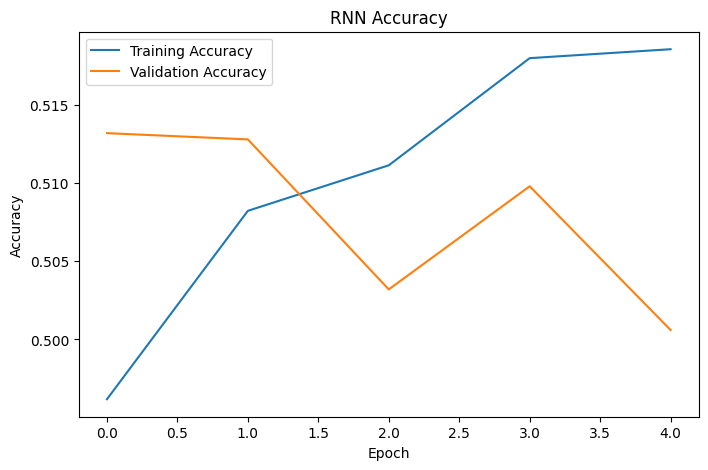

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(rnn_history.history['accuracy'], label='Training Accuracy')

plt.plot(rnn_history.history['val_accuracy'], label='Validation Accuracy')

plt.title("RNN Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

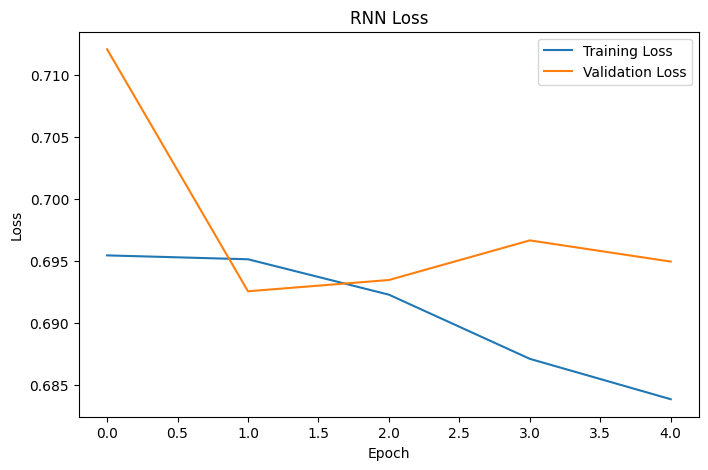

In [36]:
plt.figure(figsize=(8,5))

plt.plot(rnn_history.history['loss'], label='Training Loss')

plt.plot(rnn_history.history['val_loss'], label='Validation Loss')

plt.title("RNN Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


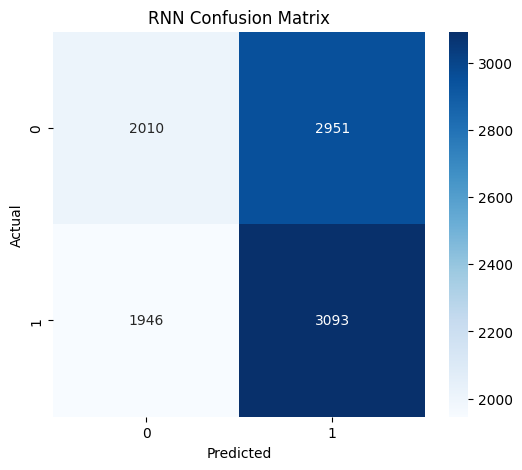

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predictions
rnn_predictions = (rnn_model.predict(X_test_pad) > 0.5).astype("int32")

# Confusion matrix
cm = confusion_matrix(y_test, rnn_predictions)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("RNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [38]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rnn_predictions
    )
)

              precision    recall  f1-score   support

           0       0.51      0.41      0.45      4961
           1       0.51      0.61      0.56      5039

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.50     10000
weighted avg       0.51      0.51      0.50     10000



In [39]:
from tensorflow.keras.layers import LSTM

# Build model
lstm_model = Sequential()

# Embedding layer
lstm_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    )
)

# LSTM layer
lstm_model.add(LSTM(64))

# Output layer
lstm_model.add(Dense(1, activation='sigmoid'))

# Summary
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [40]:
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [41]:
lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 126s 113ms/step - accuracy: 0.5041 - loss: 0.6931 - val_accuracy: 0.5010 - val_loss: 0.6944
Epoch 2/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 125s 114ms/step - accuracy: 0.5162 - loss: 0.6807 - val_accuracy: 0.5032 - val_loss: 0.6897
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 123s 112ms/step - accuracy: 0.5366 - loss: 0.6598 - val_accuracy: 0.6768 - val_loss: 0.6303
Epoch 4/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 121s 111ms/step - accuracy: 0.8287 - loss: 0.3985 - val_accuracy: 0.8606 - val_loss: 0.3433
Epoch 5/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 142s 110ms/step - accuracy: 0.9073 - loss: 0.2479 - val_accuracy: 0.8734 - val_loss: 0.3172
Epoch 6/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 143s 111ms/step - accuracy: 0.9364 - loss: 0.1802 - val_accuracy: 0.8746 - val_loss: 0.3529
Epoch 7/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 119s 109ms/step - accuracy: 0.9587 - loss: 0.1294 - val_accuracy: 0.8732 - val_loss: 0.3698
Epoch 8/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 144s 111ms/step - ac

In [42]:
lstm_loss, lstm_accuracy = lstm_model.evaluate(
    X_test_pad,
    y_test
)

print("LSTM Test Accuracy:", lstm_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8759 - loss: 0.3032
LSTM Test Accuracy: 0.8758999705314636


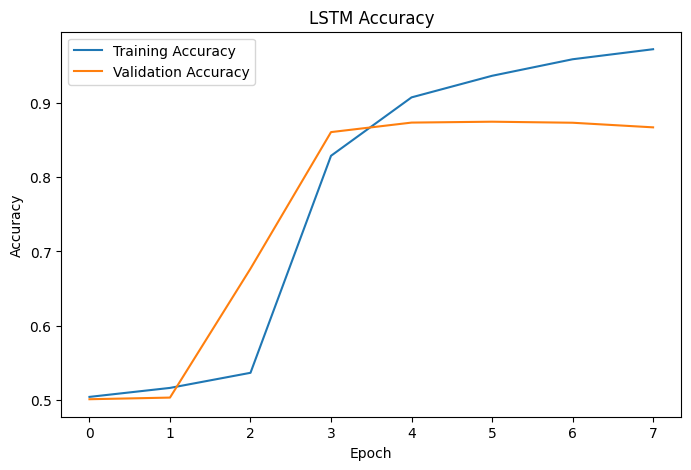

In [43]:
plt.figure(figsize=(8,5))

plt.plot(lstm_history.history['accuracy'], label='Training Accuracy')

plt.plot(lstm_history.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

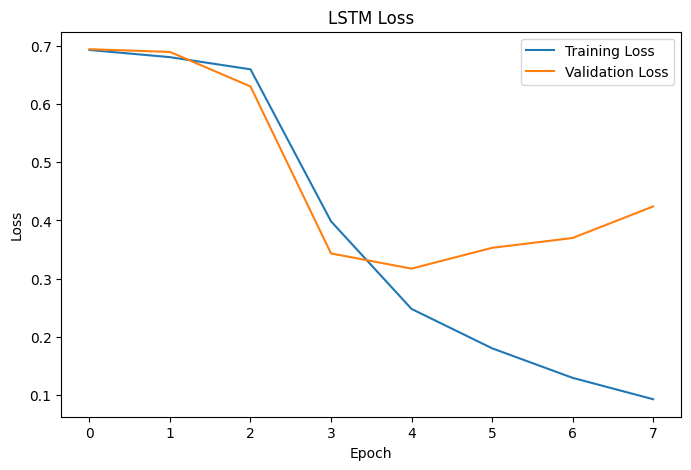

In [44]:
plt.figure(figsize=(8,5))

plt.plot(lstm_history.history['loss'], label='Training Loss')

plt.plot(lstm_history.history['val_loss'], label='Validation Loss')

plt.title("LSTM Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step


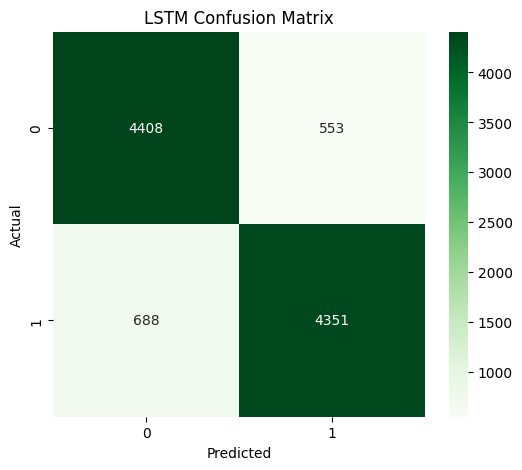

In [45]:
# Predictions
lstm_predictions = (
    lstm_model.predict(X_test_pad) > 0.5
).astype("int32")

# Confusion matrix
cm = confusion_matrix(y_test, lstm_predictions)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("LSTM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [46]:
print(
    classification_report(
        y_test,
        lstm_predictions
    )
)

              precision    recall  f1-score   support

           0       0.86      0.89      0.88      4961
           1       0.89      0.86      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [47]:
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.0 MB/s eta 0:00:00


In [48]:
import gensim.downloader as api

# Pretrained Word2Vec model (Google News)
word2vec = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [49]:
embedding_dim = 300

word_index = tokenizer.word_index

vocab_size = 10000

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
    if i < vocab_size:
        try:
            embedding_vector = word2vec[word]
            embedding_matrix[i] = embedding_vector
        except:
            pass

In [50]:
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.models import Sequential

w2v_lstm = Sequential()

w2v_lstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=False   # IMPORTANT: pretrained fixed embeddings
    )
)

w2v_lstm.add(LSTM(64))

w2v_lstm.add(Dense(1, activation='sigmoid'))

w2v_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,000 (11.44 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,000,000 (11.44 MB)

In [51]:
w2v_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [52]:
w2v_history = w2v_lstm.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 166s 150ms/step - accuracy: 0.5312 - loss: 0.6836 - val_accuracy: 0.5136 - val_loss: 0.6904
Epoch 2/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 164s 150ms/step - accuracy: 0.5712 - loss: 0.6522 - val_accuracy: 0.8392 - val_loss: 0.3740
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 162s 148ms/step - accuracy: 0.8567 - loss: 0.3373 - val_accuracy: 0.8636 - val_loss: 0.3159
Epoch 4/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 159s 146ms/step - accuracy: 0.8756 - loss: 0.2971 - val_accuracy: 0.8726 - val_loss: 0.3002
Epoch 5/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 200s 144ms/step - accuracy: 0.8831 - loss: 0.2807 - val_accuracy: 0.8754 - val_loss: 0.2896
Epoch 6/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 157s 143ms/step - accuracy: 0.8913 - loss: 0.2642 - val_accuracy: 0.8758 - val_loss: 0.3001
Epoch 7/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 204s 145ms/step - accuracy: 0.8973 - loss: 0.2510 - val_accuracy: 0.8684 - val_loss: 0.3020
Epoch 8/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 162s 148ms/step - ac

In [53]:
w2v_loss, w2v_acc = w2v_lstm.evaluate(X_test_pad, y_test)

print("Word2Vec + LSTM Accuracy:", w2v_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.8754 - loss: 0.2919
Word2Vec + LSTM Accuracy: 0.8754000067710876


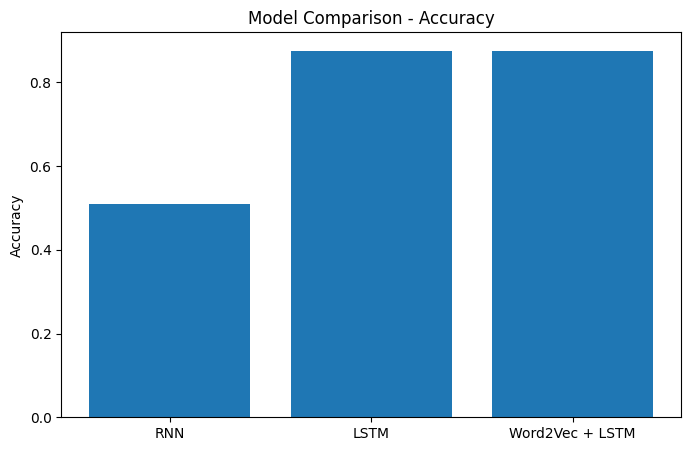

In [54]:
models = ['RNN', 'LSTM', 'Word2Vec + LSTM']

accuracy = [
    rnn_accuracy,
    lstm_accuracy,
    w2v_acc
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.title("Model Comparison - Accuracy")

plt.ylabel("Accuracy")

plt.show()

In [55]:
comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy
})

comparison

,Model,Accuracy
0,RNN,0.5103
1,LSTM,0.8759
2,Word2Vec + LSTM,0.8754


In [56]:
import numpy as np

# predictions from best model (choose LSTM or Word2Vec)
preds = (lstm_model.predict(X_test_pad) > 0.5).astype("int32")

errors = np.where(preds.flatten() != np.array(y_test))[0]

print("Number of misclassified samples:", len(errors))

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
Number of misclassified samples: 1241


In [57]:
for i in errors[:5]:
    print("\n--- MISCLASSIFIED SAMPLE ---")
    print("Review:", X_test.iloc[i])
    print("Actual:", y_test.iloc[i])
    print("Predicted:", preds[i][0])


--- MISCLASSIFIED SAMPLE ---
Review: really liked summerslam due look arena curtain look overall interesting reason anyways could one best summerslams ever wwf lex luger main event yokozuna time ok huge fat man v strong man glad time changed terrible main event like every match luger terrible match card razor ramon v ted dibiase steiner brother v heavenly body shawn michael v curt hening event shawn named big monster body guard diesel irs v kid bret hart first take doink take jerry lawler stuff hart lawler always interesting ludvig borga destroyed marty jannetty undertaker took giant gonzalez another terrible match smoking gunns tatanka took bam bam bigelow headshrinkers yokozuna defended world title lex luger match boring terrible ending however deserves
Actual: 1
Predicted: 0

--- MISCLASSIFIED SAMPLE ---
Review: okay get purgatory thing first time watched episode seemed like something significant going could put finger time costa mesa fire tv really caught attention helped writing 

In [59]:
!pip install gradio -q

In [60]:
def predict_sentiment(text):

    # clean input
    text = clean_text(text)

    # tokenize
    seq = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(seq, maxlen=max_length, padding='post')

    # prediction (use best model → LSTM)
    pred = lstm_model.predict(padded)[0][0]

    if pred > 0.5:
        return "Positive 😊"
    else:
        return "Negative 😞"

In [61]:
import gradio as gr

interface = gr.Interface(
    fn=predict_sentiment,
    inputs="text",
    outputs="text",
    title="Movie Review Sentiment Analysis",
    description="Enter a movie review and get sentiment prediction"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://78a5b320beb28c57f2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
